# Task 4 — Statistical Inferential Hypothesis Analysis & Predictive Business Forecaster

This project performs statistical hypothesis testing and predictive business forecasting using the Sample Superstore dataset.

### Main Components
1. Data loading and preparation
2. Exploratory Data Analysis
3. Data quality assessment
4. Statistical hypothesis testing (T-Test, ANOVA, Chi-Square)
5. Multivariate regression (Sales prediction)
6. SARIMA time-series forecasting with 95% prediction intervals
7. Export of results for Power BI

In [1]:
# Installing required libraries
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.multicomp import pairwise_tukeyhsd   

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Load the Dataset

The Sample Superstore CSV file is loaded into a Pandas DataFrame for analysis.

In [3]:
import pandas as pd

# Load dataset
file_path = r"C:\Users\hp\Documents\Progree Internship Tasks or Project Documents\Task 4\Task 4 Documents\extracted csv\Sample - Superstore.csv"
df = pd.read_csv(file_path, encoding='latin1')

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 9994
Columns: 21


# 2. Initial Dataset Inspection

This section examines the structure, variables, data types, and first observations of the dataset.

In [4]:
# Display first five rows

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Display last five rows

df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
# Statistical summary of numerical variables

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Column names

print("Columns in the dataset:")
for column in df.columns:
    print("-", column)

Columns in the dataset:
- Row ID
- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Postal Code
- Region
- Product ID
- Category
- Sub-Category
- Product Name
- Sales
- Quantity
- Discount
- Profit


# 3. Data Quality Assessment

The dataset is checked for:

- Missing values
- Duplicate records
- Incorrect data types
- Potential data-quality issues

In [9]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [10]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [11]:
# Check unique values for categorical variables

categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "Region",
    "Category",
    "Sub-Category"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Ship Mode:
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment:
['Consumer' 'Corporate' 'Home Office']

Country:
['United States']

Region:
['South' 'West' 'Central' 'East']

Category:
['Furniture' 'Office Supplies' 'Technology']

Sub-Category:
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


# 4. Date Conversion and Time Features

The Order Date and Ship Date columns are converted into datetime format.

Additional time-based variables are created to support exploratory analysis and time-series forecasting.

In [12]:
# Convert date columns

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [13]:
# Create time-related variables

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

print(df[[
    "Order Date",
    "Order Year",
    "Order Month",
    "Month Name",
    "Quarter"
]].head())

  Order Date  Order Year  Order Month Month Name  Quarter
0 2016-11-08        2016           11   November        4
1 2016-11-08        2016           11   November        4
2 2016-06-12        2016            6       June        2
3 2015-10-11        2015           10    October        4
4 2015-10-11        2015           10    October        4


# 5. Descriptive Business Analysis

This section examines the major enterprise metrics:

- Sales
- Profit
- Quantity
- Discount

The objective is to understand the overall business performance before conducting inferential analysis.

In [14]:
# Descriptive statistics for key business metrics

business_metrics = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

df[business_metrics].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [15]:
# Overall business KPIs

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_discount = df["Discount"].mean()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Average Discount: {average_discount:.2%}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity: 37,873
Average Discount: 15.62%


# 6. Exploratory Data Visualization

Visualizations are used to identify patterns and relationships in the business metrics before statistical testing and predictive modeling.

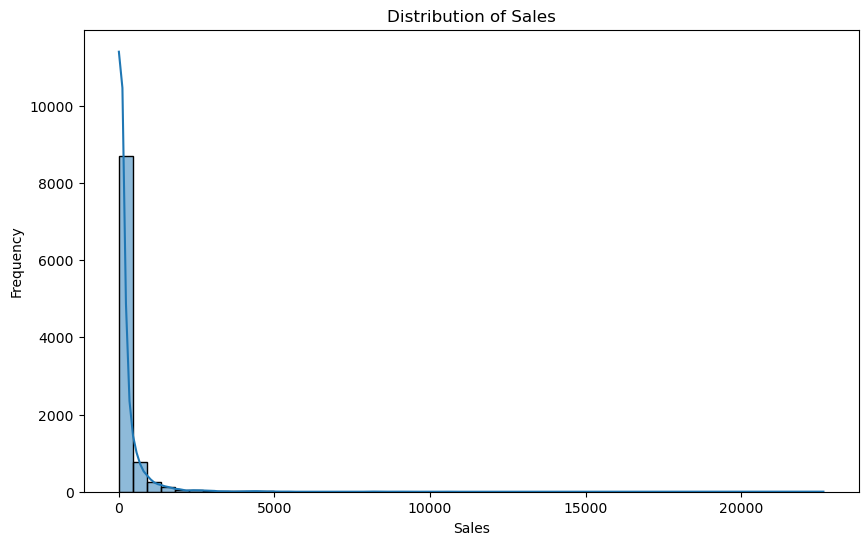

In [16]:
# Sales distribution

plt.figure(figsize=(10, 6))
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

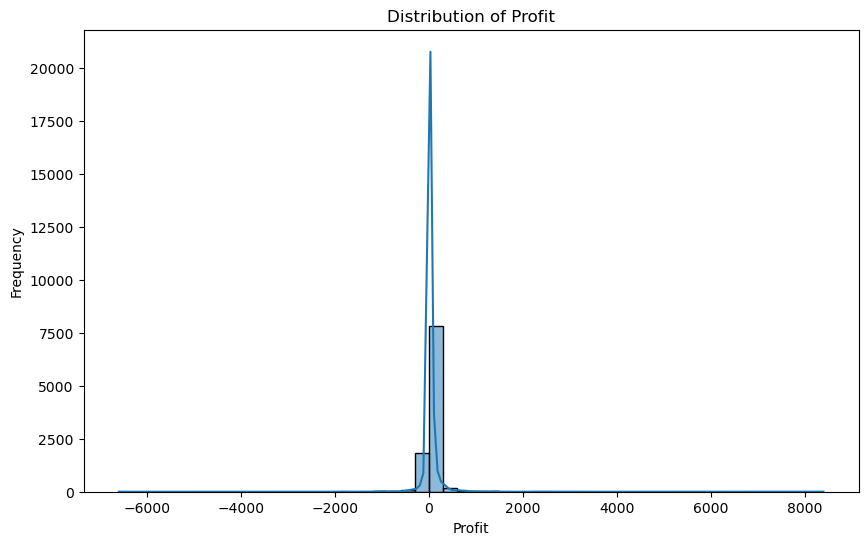

In [17]:
# Profit distribution

plt.figure(figsize=(10, 6))
sns.histplot(df["Profit"], bins=50, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

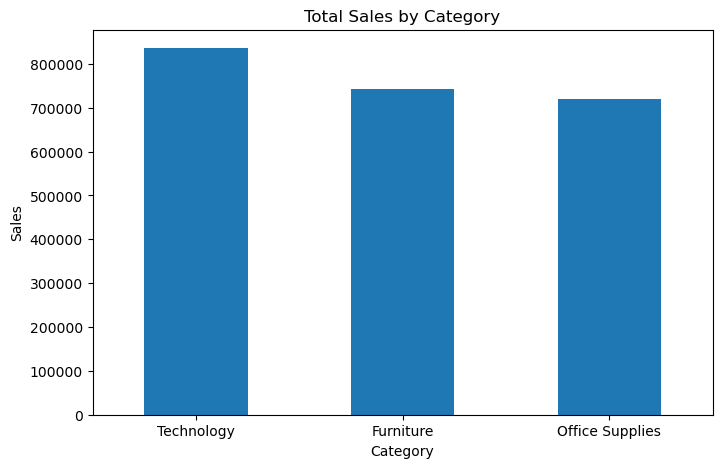

In [18]:
# Sales by category

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

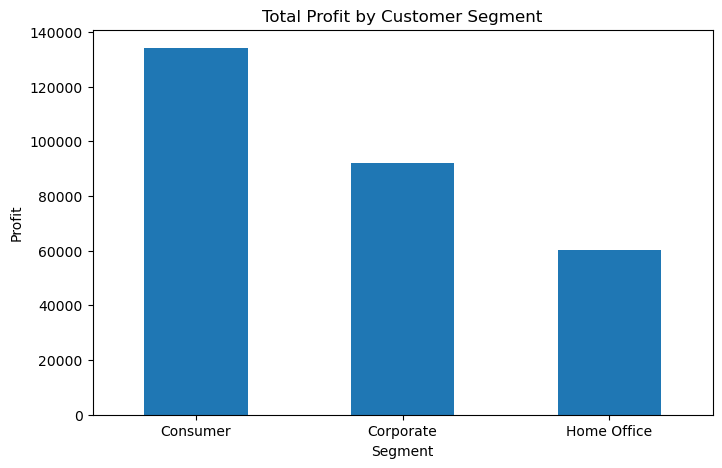

In [19]:
# Profit by customer segment

segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
segment_profit.plot(kind="bar")
plt.title("Total Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

# 7. Correlation Analysis

Correlation analysis is used to examine relationships between numerical business variables.

In [20]:
# Correlation matrix

correlation_matrix = df[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


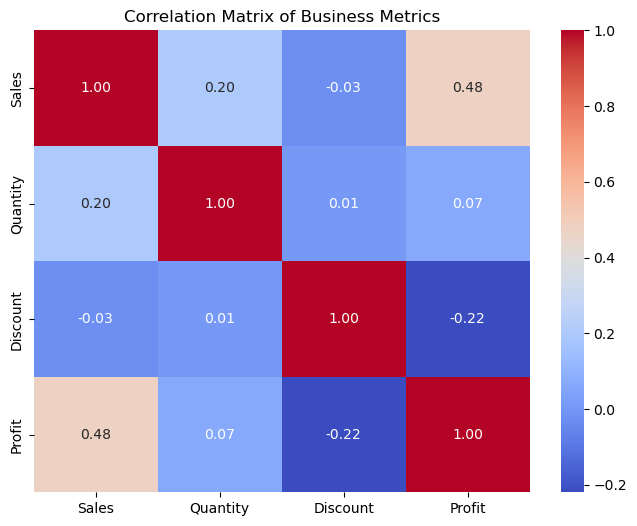

In [21]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Business Metrics")
plt.show()

# 8. Statistical Hypothesis Testing

To make the hypothesis tests more statistically defensible, transaction-level records are aggregated where appropriate.

This reduces the problem of treating multiple line items from the same order or customer as completely independent observations.

In [22]:
# Create order-level dataset

order_level = (
    df.groupby("Order ID")
      .agg(
          Order_Profit=("Profit", "sum"),
          Order_Sales=("Sales", "sum"),
          Order_Quantity=("Quantity", "sum"),
          Average_Discount=("Discount", "mean"),
          Segment=("Segment", "first"),
          Region=("Region", "first"),
          Category=("Category", "first")
      )
      .reset_index()
)

# Create discount group

order_level["Discount_Group"] = np.where(
    order_level["Average_Discount"] > 0,
    "Discounted",
    "No Discount"
)

order_level.head()

,Order ID,Order_Profit,Order_Sales,Order_Quantity,Average_Discount,Segment,Region,Category,Discount_Group
0,CA-2014-100006,109.6113,377.970,3,0.0,Consumer,East,Technology,No Discount
1,CA-2014-100090,-19.0890,699.192,9,0.2,Corporate,West,Furniture,Discounted
2,CA-2014-100293,31.8696,91.056,6,0.2,Home Office,South,Office Supplies,Discounted
3,CA-2014-100328,1.3257,3.928,1,0.2,Consumer,East,Office Supplies,Discounted
4,CA-2014-100363,7.7192,21.376,5,0.2,Corporate,West,Office Supplies,Discounted


## 8.1 Two-Group Hypothesis Test — Discount vs No Discount

### Business Question

Does average order profit differ significantly between discounted and non-discounted orders?

### Null Hypothesis (H₀)

There is no significant difference in mean order profit between discounted and non-discounted orders.

### Alternative Hypothesis (H₁)

There is a significant difference in mean order profit between discounted and non-discounted orders.

### Significance Level

α = 0.05

Welch's independent two-sample t-test is used because the two groups may have unequal variances.

In [23]:
# Separate groups

no_discount_profit = order_level.loc[
    order_level["Discount_Group"] == "No Discount",
    "Order_Profit"
]

discounted_profit = order_level.loc[
    order_level["Discount_Group"] == "Discounted",
    "Order_Profit"
]

print("No Discount orders:", len(no_discount_profit))
print("Discounted orders:", len(discounted_profit))

print("\nMean Order Profit:")
print(f"No Discount: ${no_discount_profit.mean():,.2f}")
print(f"Discounted: ${discounted_profit.mean():,.2f}")

No Discount orders: 2055
Discounted orders: 2954

Mean Order Profit:
No Discount: $123.94
Discounted: $10.73


In [24]:
# Welch's independent two-sample t-test

ttest_statistic, ttest_p_value = ttest_ind(
    no_discount_profit,
    discounted_profit,
    equal_var=False
)

print(f"T-statistic: {ttest_statistic:.4f}")
print(f"P-value: {ttest_p_value:.10f}")

alpha = 0.05

if ttest_p_value < alpha:
    ttest_decision = "Reject H₀"
    ttest_conclusion = (
        "There is statistically significant evidence "
        "that mean order profit differs between the two groups."
    )
else:
    ttest_decision = "Fail to reject H₀"
    ttest_conclusion = (
        "There is insufficient evidence of a statistically "
        "significant difference in mean order profit."
    )

print(f"\nDecision: {ttest_decision}")
print(f"Conclusion: {ttest_conclusion}")

T-statistic: 11.1268
P-value: 0.0000000000

Decision: Reject H₀
Conclusion: There is statistically significant evidence that mean order profit differs between the two groups.


In [25]:
# Calculate 95% confidence interval for difference in means

mean_difference = (
    no_discount_profit.mean() - discounted_profit.mean()
)

n1 = len(no_discount_profit)
n2 = len(discounted_profit)

var1 = no_discount_profit.var(ddof=1)
var2 = discounted_profit.var(ddof=1)

standard_error = np.sqrt(
    (var1 / n1) + (var2 / n2)
)

# Welch-Satterthwaite degrees of freedom

welch_df = (
    ((var1 / n1) + (var2 / n2)) ** 2
    /
    (
        ((var1 / n1) ** 2 / (n1 - 1))
        +
        ((var2 / n2) ** 2 / (n2 - 1))
    )
)

critical_value = stats.t.ppf(
    0.975,
    welch_df
)

margin_of_error = critical_value * standard_error

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print(f"Mean difference: ${mean_difference:,.2f}")
print(f"95% CI: (${ci_lower:,.2f}, ${ci_upper:,.2f})")

Mean difference: $113.20
95% CI: ($93.26, $133.15)


# 9. ANOVA — Customer Profitability Across Segments

Customer-level total profit is used to compare profitability across the three customer segments.

### Groups

- Consumer
- Corporate
- Home Office

### Null Hypothesis (H₀)

Mean customer-level profit is equal across all customer segments.

### Alternative Hypothesis (H₁)

At least one customer segment has a different mean customer-level profit.

### Significance Level

α = 0.05

In [26]:
# Create customer-level dataset

customer_level = (
    df.groupby("Customer ID")
      .agg(
          Customer_Profit=("Profit", "sum"),
          Customer_Sales=("Sales", "sum"),
          Segment=("Segment", "first"),
          Region=("Region", "first")
      )
      .reset_index()
)

customer_level.head()

,Customer ID,Customer_Profit,Customer_Sales,Segment,Region
0,AA-10315,-362.8825,5563.560,Consumer,Central
1,AA-10375,277.3824,1056.390,Consumer,West
2,AA-10480,435.8274,1790.512,Consumer,South
3,AA-10645,857.8033,5086.935,Consumer,East
4,AB-10015,129.3465,886.156,Consumer,West


In [27]:
# Create groups

consumer_profit = customer_level.loc[
    customer_level["Segment"] == "Consumer",
    "Customer_Profit"
]

corporate_profit = customer_level.loc[
    customer_level["Segment"] == "Corporate",
    "Customer_Profit"
]

home_office_profit = customer_level.loc[
    customer_level["Segment"] == "Home Office",
    "Customer_Profit"
]

print(f"Consumer customers: {len(consumer_profit)}")
print(f"Corporate customers: {len(corporate_profit)}")
print(f"Home Office customers: {len(home_office_profit)}")

print("\nMean Customer Profit:")
print(f"Consumer: ${consumer_profit.mean():,.2f}")
print(f"Corporate: ${corporate_profit.mean():,.2f}")
print(f"Home Office: ${home_office_profit.mean():,.2f}")

Consumer customers: 409
Corporate customers: 236
Home Office customers: 148

Mean Customer Profit:
Consumer: $327.92
Corporate: $389.74
Home Office: $407.42


In [28]:
# One-way ANOVA

anova_statistic, anova_p_value = f_oneway(
    consumer_profit,
    corporate_profit,
    home_office_profit
)

print(f"F-statistic: {anova_statistic:.4f}")
print(f"P-value: {anova_p_value:.10f}")

if anova_p_value < 0.05:
    anova_decision = "Reject H₀"
    anova_conclusion = (
        "At least one customer segment has a statistically "
        "different mean customer-level profit."
    )
else:
    anova_decision = "Fail to reject H₀"
    anova_conclusion = (
        "There is insufficient evidence that mean customer-level "
        "profit differs across customer segments."
    )

print(f"\nDecision: {anova_decision}")
print(f"Conclusion: {anova_conclusion}")

F-statistic: 0.6005
P-value: 0.5487682155

Decision: Fail to reject H₀
Conclusion: There is insufficient evidence that mean customer-level profit differs across customer segments.


In [29]:
# Tukey HSD post-hoc analysis

tukey_result = pairwise_tukeyhsd(
    endog=customer_level["Customer_Profit"],
    groups=customer_level["Segment"],
    alpha=0.05
)

print(tukey_result)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1     group2   meandiff p-adj    lower    upper   reject
---------------------------------------------------------------
 Consumer   Corporate  61.8223 0.6749 -109.9167 233.5613  False
 Consumer Home Office  79.5037 0.6238 -122.0273 281.0347  False
Corporate Home Office  17.6814 0.9806 -202.6039 237.9667  False
---------------------------------------------------------------


# 10. Chi-Square Test — Customer Segment vs Region

The Chi-Square test evaluates whether customer segment and region are statistically associated.

Each customer is counted once to avoid giving customers with more transactions disproportionate influence.

### Null Hypothesis (H₀)

Customer Segment and Region are independent.

### Alternative Hypothesis (H₁)

Customer Segment and Region are associated.

### Significance Level

α = 0.05

In [30]:
# Create unique customer-segment-region combinations

customer_region = (
    df[["Customer ID", "Segment", "Region"]]
    .drop_duplicates("Customer ID")
)

contingency_table = pd.crosstab(
    customer_region["Segment"],
    customer_region["Region"]
)

print("Contingency Table:")
display(contingency_table)

Contingency Table:


Region,Central,East,South,West
Segment,,,,
Consumer,90,110,68,141
Corporate,58,67,41,70
Home Office,36,43,25,44


In [31]:
# Chi-Square test

chi_square_statistic, chi_square_p_value, chi_square_df, expected_frequencies = (
    chi2_contingency(contingency_table)
)

print(f"Chi-Square statistic: {chi_square_statistic:.4f}")
print(f"Degrees of freedom: {chi_square_df}")
print(f"P-value: {chi_square_p_value:.10f}")

if chi_square_p_value < 0.05:
    chi_square_decision = "Reject H₀"
    chi_square_conclusion = (
        "There is statistically significant evidence of an association "
        "between customer segment and region."
    )
else:
    chi_square_decision = "Fail to reject H₀"
    chi_square_conclusion = (
        "There is insufficient evidence of an association "
        "between customer segment and region."
    )

print(f"\nDecision: {chi_square_decision}")
print(f"Conclusion: {chi_square_conclusion}")

Chi-Square statistic: 2.2192
Degrees of freedom: 6
P-value: 0.8984752976

Decision: Fail to reject H₀
Conclusion: There is insufficient evidence of an association between customer segment and region.


# 11. Multivariate Regression — Sales Prediction

A multivariate regression model is developed to predict Sales using multiple business-related predictors.

### Target Variable

Sales

### Predictors

- Quantity
- Discount
- Segment
- Category
- Region
- Ship Mode

The model is evaluated on unseen test data using R², MAE and RMSE.

In [32]:
# Regression dataset

regression_data = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Segment",
        "Category",
        "Region",
        "Ship Mode"
    ]
].copy()

X = regression_data.drop("Sales", axis=1)
y = regression_data["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 7995
Testing observations: 1999


In [33]:
# Define features

numerical_features = [
    "Quantity",
    "Discount"
]

categorical_features = [
    "Segment",
    "Category",
    "Region",
    "Ship Mode"
]

# Preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

# Regression pipeline

sales_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train

sales_regression_model.fit(
    X_train,
    y_train
)

print("Sales regression model trained successfully.")

Sales regression model trained successfully.


In [34]:
# Predictions

sales_predictions = sales_regression_model.predict(X_test)

# Evaluation metrics

sales_r2 = r2_score(
    y_test,
    sales_predictions
)

sales_mae = mean_absolute_error(
    y_test,
    sales_predictions
)

sales_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        sales_predictions
    )
)

print(f"R²: {sales_r2:.4f}")
print(f"MAE: ${sales_mae:,.2f}")
print(f"RMSE: ${sales_rmse:,.2f}")

R²: 0.0798
MAE: $249.28
RMSE: $737.26


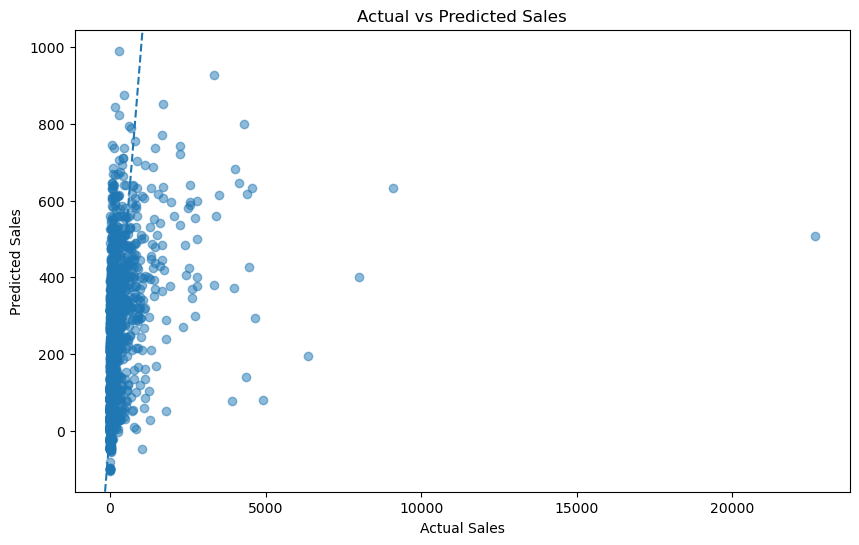

In [35]:
# Actual vs predicted sales

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    sales_predictions,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.show()

# 12. SARIMA Model Selection

Multiple SARIMA configurations are evaluated rather than assuming a single model specification.

Models are compared using:

- AIC
- MAE
- RMSE
- MAPE

The final model will be selected based on forecasting performance and model diagnostics.

In [36]:
# Prepare monthly sales

monthly_sales = (
    df.set_index("Order Date")
      .resample("MS")["Sales"]
      .sum()
)

# Chronological train/test split

train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 36
Testing observations: 12


In [37]:
# Candidate SARIMA models

candidate_models = [
    ((1, 1, 1), (1, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 1, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((1, 0, 1), (1, 1, 0, 12))
]

sarima_results = []

for order, seasonal_order in candidate_models:

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        result = model.fit(disp=False)

        forecast_result = result.get_forecast(
            steps=len(test)
        )

        predictions = forecast_result.predicted_mean

        mae = mean_absolute_error(
            test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                test,
                predictions
            )
        )

        mape = np.mean(
            np.abs((test - predictions) / test)
        ) * 100

        sarima_results.append({
            "Order": order,
            "Seasonal Order": seasonal_order,
            "AIC": result.aic,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

    except Exception as e:

        print(
            f"Model {order} x {seasonal_order} failed: {e}"
        )

sarima_comparison = pd.DataFrame(
    sarima_results
)

sarima_comparison.sort_values(
    "RMSE"
)

,Order,Seasonal Order,AIC,MAE,RMSE,MAPE
1,"(0, 1, 1)","(1, 1, 1, 12)",201.126537,12827.813837,15247.020471,25.661518
3,"(0, 1, 1)","(0, 1, 1, 12)",199.137336,13006.710975,15495.150829,25.731532
4,"(1, 1, 1)","(0, 1, 1, 12)",200.568798,13326.078493,15815.228245,26.519681
5,"(1, 0, 1)","(1, 1, 0, 12)",241.934300,13183.749354,15834.687542,26.170737
0,"(1, 1, 1)","(1, 1, 1, 12)",202.537006,13580.179345,16260.698285,26.844399
2,"(1, 1, 0)","(1, 1, 1, 12)",225.193309,19146.782130,22127.684516,45.290404


In [38]:
# Select model with lowest RMSE

best_model_row = sarima_comparison.loc[
    sarima_comparison["RMSE"].idxmin()
]

best_order = best_model_row["Order"]
best_seasonal_order = best_model_row["Seasonal Order"]

print("Best SARIMA configuration:")
print("Order:", best_order)
print("Seasonal Order:", best_seasonal_order)
print(f"AIC: {best_model_row['AIC']:.2f}")
print(f"MAE: ${best_model_row['MAE']:,.2f}")
print(f"RMSE: ${best_model_row['RMSE']:,.2f}")
print(f"MAPE: {best_model_row['MAPE']:.2f}%")

Best SARIMA configuration:
Order: (0, 1, 1)
Seasonal Order: (1, 1, 1, 12)
AIC: 201.13
MAE: $12,827.81
RMSE: $15,247.02
MAPE: 25.66%


In [39]:
# Fit the selected model on training data

best_sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_sarima_result = best_sarima_model.fit(
    disp=False
)

print(best_sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -96.563
Date:                            Fri, 11 Sep 2026   AIC                            201.127
Time:                                    10:55:51   BIC                            201.915
Sample:                                01-01-2014   HQIC                           199.424
                                     - 12-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9957      0.969     -1.028      0.304      -2.895       0.903
ar.S.L12       0.1462      1.640   

In [40]:
# Generate test-period forecast

test_forecast_result = best_sarima_result.get_forecast(
    steps=len(test)
)

test_forecast = test_forecast_result.predicted_mean

test_confidence = (
    test_forecast_result.conf_int()
)

print("Forecast generated successfully.")

Forecast generated successfully.


In [41]:
# Evaluation

final_mae = mean_absolute_error(
    test,
    test_forecast
)

final_rmse = np.sqrt(
    mean_squared_error(
        test,
        test_forecast
    )
)

final_mape = np.mean(
    np.abs((test - test_forecast) / test)
) * 100

print(f"Final SARIMA MAE: ${final_mae:,.2f}")
print(f"Final SARIMA RMSE: ${final_rmse:,.2f}")
print(f"Final SARIMA MAPE: {final_mape:.2f}%")

Final SARIMA MAE: $12,827.81
Final SARIMA RMSE: $15,247.02
Final SARIMA MAPE: 25.66%


# 13. Forecast With 95% Prediction Interval

The selected SARIMA model provides future sales forecasts together with 95% prediction intervals.

The prediction interval communicates the uncertainty surrounding future sales estimates.

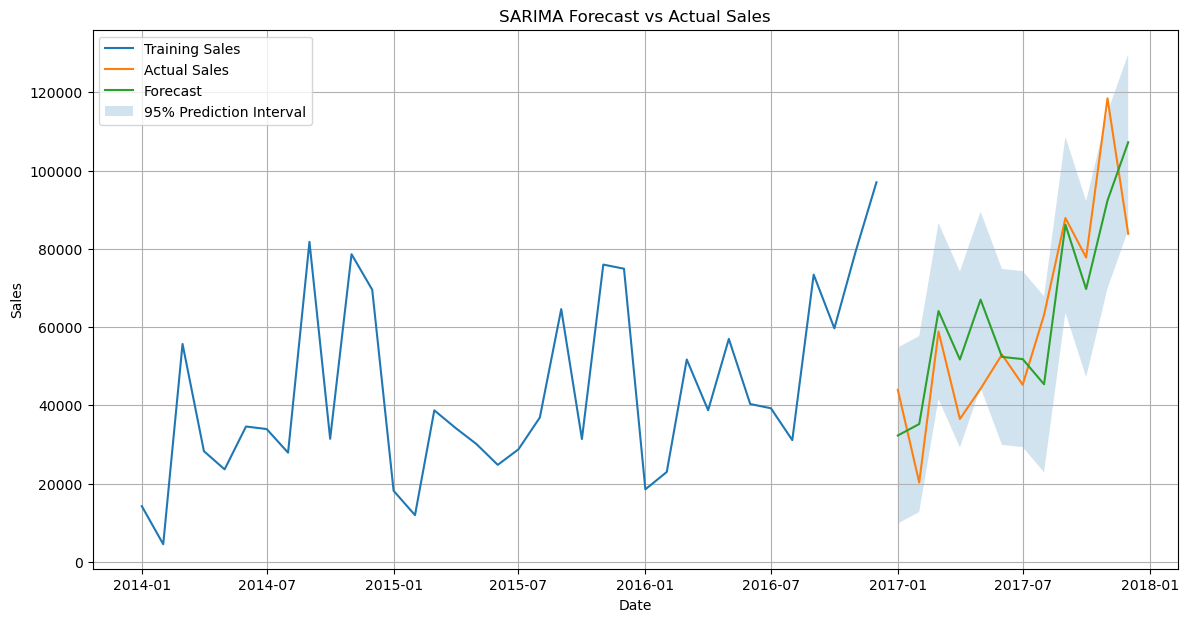

In [42]:
plt.figure(figsize=(14, 7))

plt.plot(
    train.index,
    train,
    label="Training Sales"
)

plt.plot(
    test.index,
    test,
    label="Actual Sales"
)

plt.plot(
    test_forecast.index,
    test_forecast,
    label="Forecast"
)

plt.fill_between(
    test_forecast.index,
    test_confidence.iloc[:, 0],
    test_confidence.iloc[:, 1],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title(
    "SARIMA Forecast vs Actual Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [43]:
# Refit selected SARIMA model using all historical observations

final_model = SARIMAX(
    monthly_sales,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_result = final_model.fit(
    disp=False
)

# Forecast next 12 months

future_result = final_result.get_forecast(
    steps=12
)

future_forecast = future_result.predicted_mean
future_prediction_interval = future_result.conf_int()

future_forecast_table = pd.DataFrame({
    "Forecast": future_forecast,
    "Lower 95%": future_prediction_interval.iloc[:, 0],
    "Upper 95%": future_prediction_interval.iloc[:, 1]
})

future_forecast_table

,Forecast,Lower 95%,Upper 95%
2018-01-01,49405.955663,18819.645351,79992.265974
2018-02-01,40250.040672,9453.070586,71047.010758
2018-03-01,73296.728593,42290.621875,104302.835310
2018-04-01,57015.496373,25801.648369,88229.344377
2018-05-01,67402.240213,35982.017669,98822.462757
2018-06-01,63797.550214,32172.292034,95422.808394
2018-07-01,60501.004087,28672.022028,92329.986145
2018-08-01,65363.957618,33332.536917,97395.378319
2018-09-01,98463.992622,66231.392549,130696.592695
2018-10-01,83132.061680,50699.516024,115564.607337


# 14. Statistical Test Summary

The results from the three formal hypothesis tests are consolidated into a single table for reporting and Power BI visualization.

In [44]:
# Create final statistical results table

statistical_results = pd.DataFrame({
    "Test": [
        "Welch Two-Sample T-Test",
        "One-Way ANOVA",
        "Chi-Square Test"
    ],
    "Statistic": [
        ttest_statistic,
        anova_statistic,
        chi_square_statistic
    ],
    "Degrees of Freedom": [
        welch_df,
        None,
        chi_square_df
    ],
    "P-Value": [
        ttest_p_value,
        anova_p_value,
        chi_square_p_value
    ],
    "Significance Level": [
        0.05,
        0.05,
        0.05
    ],
    "Decision": [
        ttest_decision,
        anova_decision,
        chi_square_decision
    ]
})

statistical_results

,Test,Statistic,Degrees of Freedom,P-Value,Significance Level,Decision
0,Welch Two-Sample T-Test,11.126792,3768.404128,2.554321e-28,0.05,Reject H₀
1,One-Way ANOVA,0.600535,NaN,5.487682e-01,0.05,Fail to reject H₀
2,Chi-Square Test,2.219201,6.000000,8.984753e-01,0.05,Fail to reject H₀


# 📤 EXPORTING FILES FOR POWER BI

In [45]:
# Export cleaned transaction data

df.to_csv(
    "superstore_cleaned.csv",
    index=False
)

# Export monthly sales

monthly_sales_export = monthly_sales.reset_index()

monthly_sales_export.columns = [
    "Order Date",
    "Monthly Sales"
]

monthly_sales_export.to_csv(
    "monthly_sales.csv",
    index=False
)

# Export future forecast

future_forecast_export = (
    future_forecast_table
    .reset_index()
)

future_forecast_export.columns = [
    "Forecast Date",
    "Forecast",
    "Lower 95%",
    "Upper 95%"
]

future_forecast_export.to_csv(
    "sales_forecast.csv",
    index=False
)

# Export SARIMA model comparison

sarima_comparison.to_csv(
    "sarima_model_comparison.csv",
    index=False
)

# Export statistical test results

statistical_results.to_csv(
    "statistical_test_results.csv",
    index=False
)

# Export regression predictions

regression_predictions = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": sales_predictions
})

regression_predictions.to_csv(
    "regression_predictions.csv",
    index=False
)

print("All Power BI files exported successfully.")

All Power BI files exported successfully.


# 15. Final Conclusions

The analysis found a statistically significant difference in mean profit between discounted and non-discounted orders, while customer segment differences and the relationship between segment and region were not statistically significant.

The regression model showed limited predictive power, whereas the SARIMA model provided a suitable approach for forecasting monthly sales and generated a 12-month forecast with 95% prediction intervals.

Overall, the project successfully applied hypothesis testing, regression, time-series forecasting, model evaluation, and uncertainty estimation to support business decision-making.